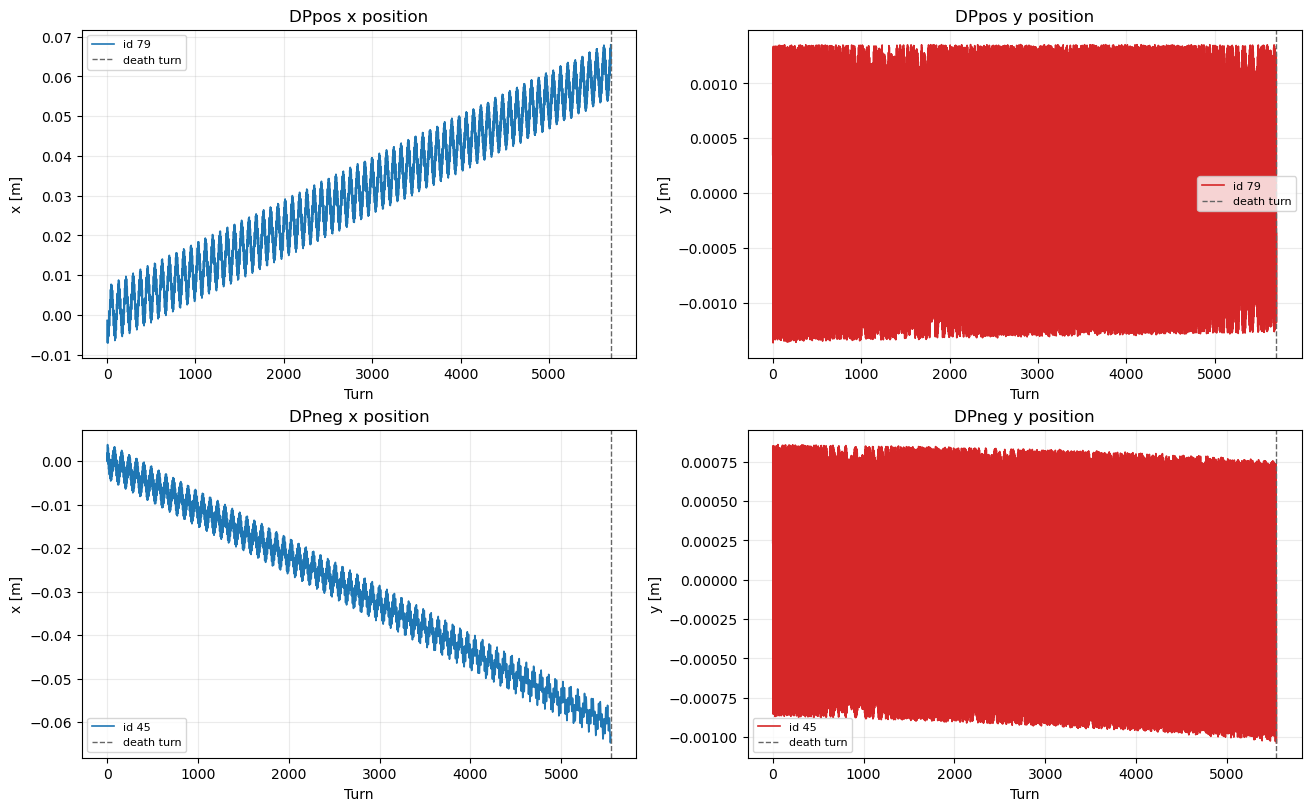

In [2]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# batch_dir = Path("tests/rf_sweep_speed_tests/dual_plane_dead_particle_diagnostics/q20_xix0p5_xiy0p5")

batch_dir = Path.cwd()
particle_ids = {
    "DPpos": 79,
    "DPneg": 45,
}

def load_npz_dict(path):
    with np.load(path, allow_pickle=False) as data:
        return {k: data[k] for k in data.files}

def particle_row_lookup(monitor_arrays):
    particle_id = np.asarray(monitor_arrays["particle_id"])
    if particle_id.ndim == 2:
        particle_id = particle_id[:, 0]
    return {int(pid): idx for idx, pid in enumerate(particle_id.astype(int, copy=False))}

def final_turn_lookup(final_arrays):
    particle_id = np.asarray(final_arrays["particle_id"]).astype(int, copy=False)
    at_turn = np.asarray(final_arrays["at_turn"]).astype(int, copy=False)
    return {int(pid): int(turn) for pid, turn in zip(particle_id, at_turn)}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
coord_colors = {"x": "tab:blue", "y": "tab:red"}

for row, plane in enumerate(["DPpos", "DPneg"]):
    monitor_arrays = load_npz_dict(batch_dir / plane / "monitor_arrays.npz")
    final_arrays = load_npz_dict(batch_dir / plane / "final_particles.npz")

    row_by_particle = particle_row_lookup(monitor_arrays)
    death_turn_by_particle = final_turn_lookup(final_arrays)

    pid = particle_ids[plane]
    rr = row_by_particle[pid]
    death_turn = death_turn_by_particle.get(pid, None)

    state = np.asarray(monitor_arrays["state"])[rr].astype(int)
    turn = np.arange(state.size)

    for col, coord in enumerate(["x", "y"]):
        ax = axes[row, col]
        values = np.asarray(monitor_arrays[coord])[rr].astype(float).copy()
        values[state <= 0] = np.nan

        ax.plot(turn, values, color=coord_colors[coord], lw=1.2, label=f"id {pid}")
        if death_turn is not None:
            ax.axvline(death_turn, color="0.4", ls="--", lw=1.0, label="death turn")

        ax.set_title(f"{plane} {coord} position")
        ax.set_xlabel("Turn")
        ax.set_ylabel(f"{coord} [m]")
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=True, fontsize=8)

plt.show()

In [4]:
from pathlib import Path
import numpy as np
import json

batch_dir = Path.cwd()

def load_npz_dict(path):
    with np.load(path, allow_pickle=False) as data:
        return {key: data[key] for key in data.files}

data = {}

for plane in ["DPpos", "DPneg"]:
    plane_dir = batch_dir / plane
    data[plane] = {
        "monitor": load_npz_dict(plane_dir / "monitor_arrays.npz"),
        "final": load_npz_dict(plane_dir / "final_particles.npz"),
        "config": json.loads((plane_dir / "run_config.json").read_text()),
    }

# convenience handles
mon_pos = data["DPpos"]["monitor"]
fin_pos = data["DPpos"]["final"]
cfg_pos = data["DPpos"]["config"]

mon_neg = data["DPneg"]["monitor"]
fin_neg = data["DPneg"]["final"]
cfg_neg = data["DPneg"]["config"]


def particle_row(monitor_arrays, particle_id):
    pid = monitor_arrays["particle_id"]
    if pid.ndim == 2:
        pid = pid[:, 0]
    matches = np.where(pid.astype(int) == int(particle_id))[0]
    if len(matches) == 0:
        raise ValueError(f"particle_id {particle_id} not found")
    return int(matches[0])


row = particle_row(mon_pos, 79)
x = mon_pos["x"][row]
y = mon_pos["y"][row]
state = mon_pos["state"][row]
delta = mon_pos["delta"][row]

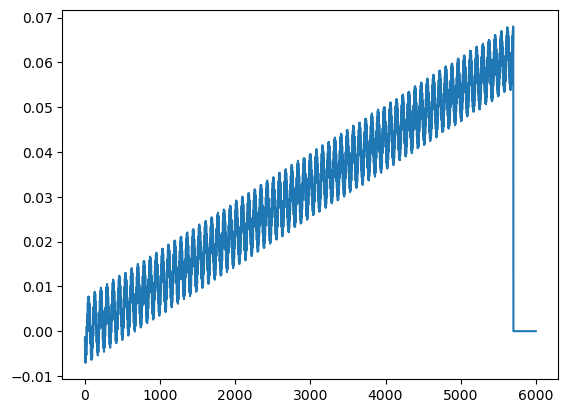

In [8]:
plt.plot(data['DPpos']['monitor']['x'][79])

In [9]:
cfg_pos.keys()

dict_keys(['line_path', 'qx', 'qy', 'xi_x', 'xi_y', 'error_variant', 'plane', 'total_sweep_hz', 'sweep_per_turn_hz', 'num_turns', 'num_particles', 'nemitt_x', 'nemitt_y', 'sigma_z', 'tune_map_path'])

In [12]:
import xtrack as xt

line = xt.load('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json')
env = line.env

_, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
line["actcse.31632"].voltage = 3.0e6

qx0 = 20.13
qy0 = 20.18
xi_x = 0.5
xi_y = 0.5

line.match(
    method="6d",
    vary=[
        xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
        xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
    ],
    targets=[
        xt.TargetSet(qx=qx0, qy=qy0, tol=1e-6, tag="tune"),
        xt.TargetSet(
            dqx=xi_x * qx0,
            dqy=xi_y * qy0,
            tol=1e-2,
            tag="chrom",
        ),
    ],
)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 15 penalty = 6.3976e-06              
Optimize - end penalty:  6.39758e-06                            


In [13]:
tw = line.twiss()
dx = tw.rows['qf.10010'].dx[0]
dy = tw.rows['qf.10010'].dy[0]
dpx = tw.rows['qf.10010'].dpx[0]
dpy = tw.rows['qf.10010'].dpy[0]

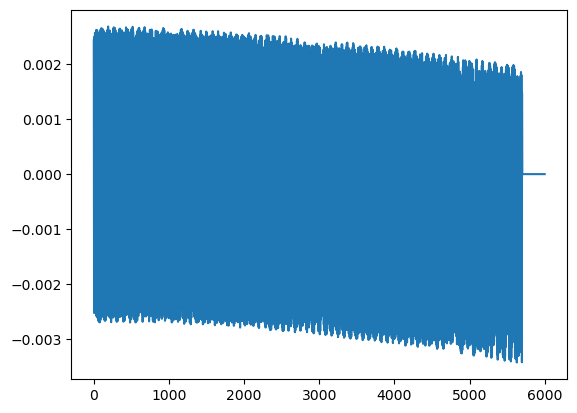

In [15]:
plt.plot(data['DPpos']['monitor']['x'][79] - dx*data['DPpos']['monitor']['delta'][79])

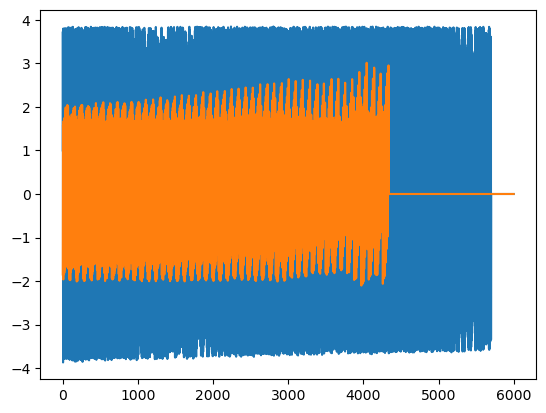

In [19]:
plt.plot(data['DPpos']['monitor']['y'][79]/data['DPpos']['monitor']['y'][79][0])
plt.plot(data['DPneg']['monitor']['x'][79]/data['DPneg']['monitor']['x'][79][0]-dx*data['DPneg']['monitor']['delta'][79]/data['DPneg']['monitor']['x'][79][0])